---
title: "2D Inversion of Ground Magnetotelluric Data"
authors:
  - id: devincowan
---

```{admonition} Intermediate notebook
:class: caution
This tutorial focusses on intermediate level functionality within SimPEG. Basic functionality within SimPEG is not discussed in detail, as we assume the user is already familiar. 
```

```{admonition} Light-weight notebook
:class: hint
This tutorial requires minimal computational resources and can be executed quickly in the background while other computer processes are running.
```

**Keywords:** Magnetotellurics, 2.5D inversion, tree mesh.

</br>

**Summary:** Here we invert ground magnetotelluric (MT) data on a tree mesh to recover the subsurface distribution of electrical conductivities. We invert impedance data corresponding to the TE mode and we invert apparent resistivity and phase data corresponding to the TM mode. Because this tutorial focusses primarily on inversion-related functionality, we urge the reader to become familiar with functionality explained in the [2D Simulation of Ground Magnetotelluric and Airborne Tipper Data](fwd_nsem_2d.ipynb) tutorial before working through this one.

</br>

**Learning Objectives:**

- Introduce the inversion magnetotelluric data with SimPEG.
- Assigning appropriate uncertainties to ground magnetotelluric data.
- Designing a suitable mesh for 2D NSEM inversion.
- Choosing suitable parameters for the inversion.
- Specifying directives that are applied throughout the inversion.
- Analyzing inversion outputs.

## Import Modules

Here, we import all of the functionality required to run the notebook for the tutorial exercise.
All of the functionality specific to natural source electromagnetics (NSEM) is imported from [simpeg.electromagnetics.natural_source](xref:simpeg#simpeg.electromagnetics.natural_source). Classes required to define the data misfit, regularization, optimization, etc... are imported from elsewhere within SimPEG. We also import some useful utility functions from [simpeg.utils](xref:simpeg#simpeg.utils). To generate the mesh used for the inversion, we use the [discretize](https://discretize.simpeg.xyz/en/main) package.

In [1]:
# SimPEG functionality
import simpeg.electromagnetics.natural_source as nsem
from simpeg.utils import (
    model_builder, get_default_solver, shift_to_discrete_topography
)
from simpeg.utils import download, model_builder
from simpeg import (
    maps,
    data,
    data_misfit,
    regularization,
    optimization,
    inverse_problem,
    inversion,
    directives,
)

# discretize functionality
from discretize import TreeMesh, TensorMesh
from discretize.utils import active_from_xyz

# Basic Python functionality
import os, re
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
import tarfile

mpl.rcParams.update({"font.size": 16})  # default font size
cmap_default = mpl.cm.Spectral_r  # default colormap

## Loading and Plotting Tutorial Data

For most geophysical inversion projects, a reasonable inversion result can be obtained so long as the practitioner has observed data, the survey geometry and topography. For this tutorial, the observed data and topography files are provided. Here, we download and import the observed data and topography into the SimPEG framework.

In [2]:
# URL to download from repository assets
# data_source = "https://github.com/simpeg/user-tutorials/raw/main/assets/05-dcr/inv_dcr_2d_files.tar.gz"

# # download the data
# downloaded_data = download(data_source, overwrite=True)

# # unzip the tarfile
# tar = tarfile.open(downloaded_data, "r")
# tar.extractall()
# tar.close()

# # path to the directory containing our data
# dir_path = downloaded_data.split(".")[0] + os.path.sep
dir_path = './fwd_nsem_2d_outputs/'

# files to work with
topo_filename = dir_path + "topo_2d.txt"
dobs_filename = dir_path + "dobs_mt.txt"

#### Loading the Topography

True surface topography is defined as an (N, 3) [numpy.ndarray](xref:numpy#numpy.ndarray).
For a 2D problem geometry however, topography is an (N, 2) [numpy.ndarray](xref:numpy#numpy.ndarray), where the first coordinate represent along-line position and the second coordinate represents the vertical position. In this tutorial, we assume the topography and measurement locations are defined according to the 2D geometry.

**For the tutorial,** we consider flat topography at an elevation of 200 m. However the notebook has been generalized to allow a user-defined topography.

:::{attention} Attention: simulations with topography
Simulating NSEM data in the presence of significant topography on structured meshes (tree or tensor) can introduce problematic numerical error. Strategies for overcoming this obstacle are being investigated; e.g. allowing NSEM simulation for unstructured meshes (e.g. triangular, tetrahedral).
:::

In [3]:
# Load 2D topography
topo_2d = np.loadtxt(str(topo_filename))

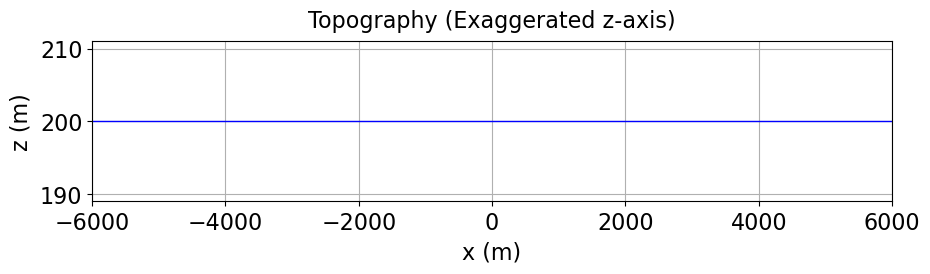

In [4]:
# Plot 2D topography
fig = plt.figure(figsize=(10, 2))
ax = fig.add_axes([0.1, 0.1, 0.8, 0.8])
ax.plot(topo_2d[:, 0], topo_2d[:, -1], color="b", linewidth=1)
ax.set_xlim([topo_2d[:, 0].min(), topo_2d[:, 0].max()])
ax.set_xlabel("x (m)", labelpad=5)
ax.set_ylabel("z (m)", labelpad=5)
ax.grid(True)
ax.set_title("Topography (Exaggerated z-axis)", fontsize=16, pad=10)
plt.show(fig)

#### Loading the Data

Here, we load the data file containing ground magnetotelluric data. **For the tutorial,** the data are organized within a text file. Each row contains the data collected at a different sounding location. The first two columns define along line positions and elevations. The remaining columns corresponding to data values for different components at different frequencies.

In [5]:
# Read first line and extract the data column headers
with open(dobs_filename, 'r', encoding='utf-8') as f:
    headers = f.readline()
headers = re.split(r'[ \n]', headers)[3:-1]
headers = [x.split("_") for x in headers]

In [6]:
# The data component and frequency can be extracted from each
# data header; e.g. "ZXYR_10.000".
components = list(dict.fromkeys([str(x[0]) for x in headers]))
frequencies = np.unique([float(x[1]) for x in headers])

n_freq = len(frequencies)
n_comp = len(components)

print(f"Frequencies (Hz): {frequencies}")
print(f"Components: {components}")

Frequencies (Hz): [   10.        31.6228   100.       316.2278  1000.      3162.2777
 10000.    ]
Components: ['ZXYR', 'ZXYI', 'RHOXY', 'PHIXY', 'ZYXR', 'ZYXI', 'RHOYX', 'PHIYX']


In [7]:
# Load the data array and parse into locations and data values
dobs_all = np.loadtxt(dobs_filename, skiprows=1)
locations = dobs_all[:, :2]  # xz locations
n_loc = len(locations)

# Reshape data array for easier plotting
# Reorganize by (n_freq, n_comp, n_loc)
dobs_all = np.reshape(dobs_all[:, 2:], (n_loc, n_comp, n_freq))
dobs_all = np.transpose(dobs_all, (2, 1, 0))

#### Plot Apparent Resistivities/Conductivities

As we discussed in the [2D Simulation of Ground Magnetotelluric and Airborne Tipper Data](fwd_nsem_2d.ipynb) tutorial, subsurface electrical resistivity/conductivity must be considered when designing the mesh used for the inversion. Here we plot the apparent resistivities/conductivities corresponding to the $Z_{xy}$ and $Z_{yx}$ impedances.

**For the tutorial,** it is clear that the host has an electrical conductivity of roughly 1e-3 S/m.

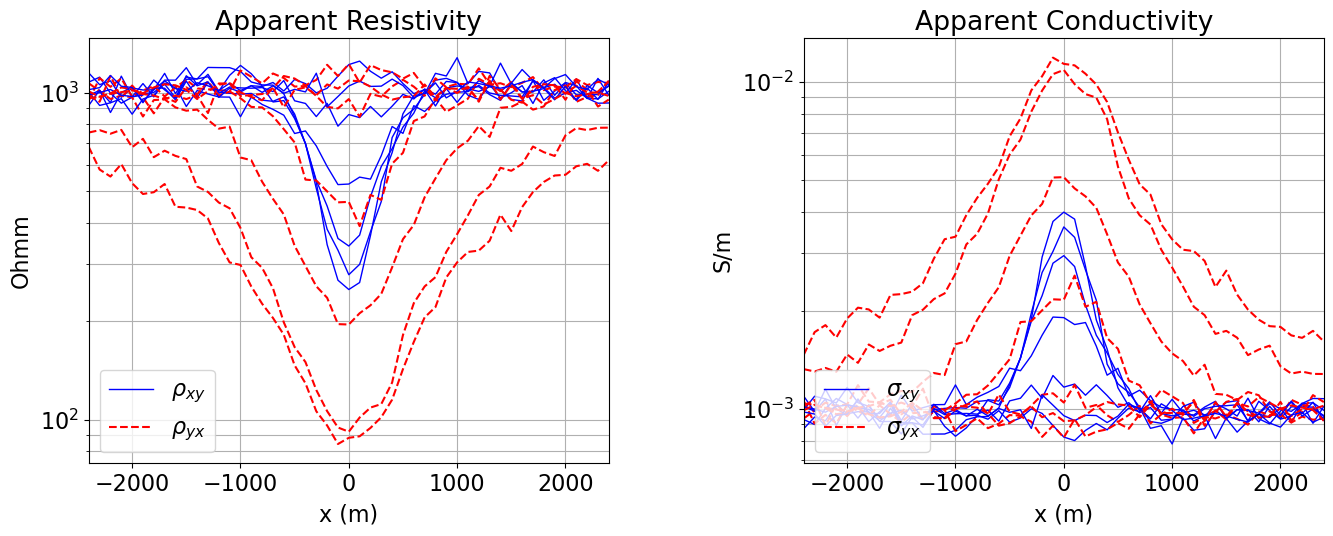

In [8]:
fig = plt.figure(figsize=(13, 5))
ax1 = fig.add_axes([0.05, 0.1, 0.4, 0.85])
ax2 = fig.add_axes([0.6, 0.1, 0.4, 0.85])

for kk in range(n_freq):
    ax1.semilogy(locations[:, 0], dobs_all[kk, 2, :], 'b', lw=1)
    ax1.semilogy(locations[:, 0], dobs_all[kk, 6, :], 'r--', lw=1.5)
    ax2.semilogy(locations[:, 0], 1/dobs_all[kk, 2, :], 'b', lw=1)
    ax2.semilogy(locations[:, 0], 1/dobs_all[kk, 6, :], 'r--', lw=1.5)

ax1.set_xlim([locations[:, 0].min(), locations[:, 0].max()])
ax1.set_xlabel("x (m)", labelpad=5)
ax1.grid(which='both')
ax1.set_ylabel("Ohmm", labelpad=5)
ax1.set_title("Apparent Resistivity")
ax1.legend(['$\\rho_{xy}$', '$\\rho_{yx}$'], loc='lower left')

ax2.set_xlim([locations[:, 0].min(), locations[:, 0].max()])
ax2.set_xlabel("x (m)", labelpad=5)
ax2.grid(which='both')
ax2.set_ylabel("S/m", labelpad=5)
ax2.set_title("Apparent Conductivity")
ax2.legend(['$\\sigma_{xy}$', '$\\sigma_{yx}$'], loc='lower left')

plt.show(fig)

## Designing a (Tree) Mesh

The same rules for defining appropriate meshes for forward simulation of ground MT data apply to inversion. Please visit the [2D Simulation of Ground Magnetotelluric and Airborne Tipper Data](fwd_nsem_2d.ipynb) tutorial to see the best practices for mesh design.

**Tutorial mesh:** Here, a minimum cell thickness and cell width of 10 m (or 1/15 the minimum skin depth for the host) is used within our survey region. This is much smaller than any of the station spacings. We use the [refine_surface](xref:discretize#discretize.TreeMesh.refine_surface) method to refine the tree mesh based on topography. We do a coarser refinement over the entire defined topography, and we do a fine refinement within the survey region. We use the [refine_points](xref:discretize#discretize.TreeMesh.refine_points) method to refine at the locations where fields are measured. The padding is at least 6x the maximum skin depth. Visit the [tree mesh](xref:discretize#discretize.TreeMesh) API to see additional refinement methods.

:::{tip}
For a flatter surface topography as one approaches the boundary, try shifting the vertical position of the mesh so that the middle lines up with the elevation of your surface topography in the survey region.
:::

In [9]:
# Skin depths for host
500. / np.sqrt(frequencies * 1e-3)

array([5000.        , 2811.70558573, 1581.13883008,  889.13965724,
        500.        ,  281.17066082,  158.11388301])

In [10]:
dh = 10  # base cell width
dom_width_x = 40000.0  # domain width x
dom_width_z = 40000.0  # domain width z
nbcx = 2 ** int(np.round(np.log(dom_width_x / dh) / np.log(2.0)))  # num. base cells x
nbcz = 2 ** int(np.round(np.log(dom_width_z / dh) / np.log(2.0)))  # num. base cells z

# Define the base mesh with top at z = 0 m.
hx = [(dh, nbcx)]
hz = [(dh, nbcz)]
mesh = TreeMesh([hx, hz], x0="CC", diagonal_balance=True)

# Shift vertically by maximum topography
mesh.origin = mesh.origin + np.r_[0.0, topo_2d[:, -1].max()]

# Coarse mesh refinement based on topography
mesh.refine_surface(
    topo_2d,
    padding_cells_by_level=[0, 0, 4, 4, 8, 8],
    finalize=False,
)

# Mesh refinement for core region
inds = (topo_2d[:, 0] > -2800.) & (topo_2d[:, 0] < 2800.)
mesh.refine_surface(
    topo_2d[inds, :],
    # padding_cells_by_level=[10, 10, 10, 6, 6, 6, 4],
    padding_cells_by_level=[8, 8, 6, 6, 6, 4],
    finalize=False,
)

# Refine around receiver locations
mesh.refine_points(
    # locations, padding_cells_by_level=[6, 6, 6, 4, 4], finalize=False
    locations, padding_cells_by_level=[4, 4, 4, 4], finalize=False
)

mesh.finalize()

In [11]:
mesh.n_cells

21082

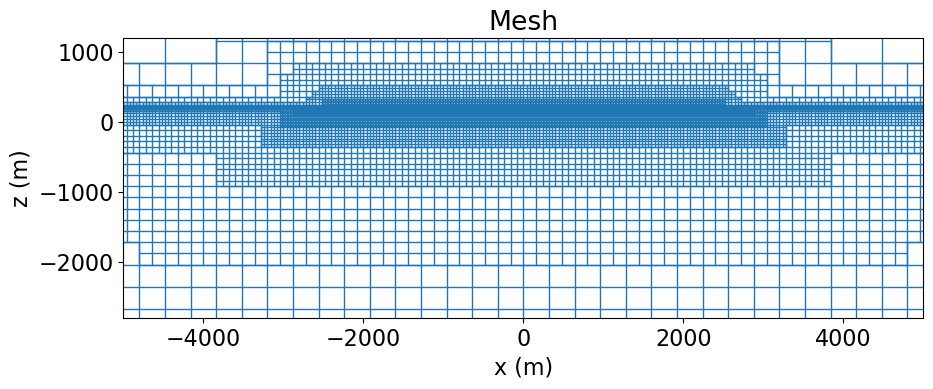

In [12]:
fig = plt.figure(figsize=(10, 4))

ax1 = fig.add_axes([0.14, 0.17, 0.8, 0.7])
mesh.plot_grid(ax=ax1, linewidth=1)
ax1.grid(False)
ax1.set_xlim(-5000, 5000)
ax1.set_ylim(np.max(topo_2d[:, -1]) - 3000, np.max(topo_2d[:, -1])+1000)
ax1.set_title("Mesh")
ax1.set_xlabel("x (m)")
ax1.set_ylabel("z (m)")

plt.show()

## Defining the Active Cells

Simulated geophysical data are dependent on the subsurface distribution of physical property values. As a result, the cells lying below the surface topography are commonly referred to as 'active cells'. And air cells, whose physical property values are fixed, are commonly referred to as 'inactive cells'. Here, the discretize [active_from_xyz](xref:discretize#discretize.utils.active_from_xyz) utility function is used to find the indices of the active cells using the mesh and surface topography. The output quantity is a ``bool`` array.

In [13]:
# Indices of the active mesh cells from topography (e.g. cells below surface)
active_cells = active_from_xyz(mesh, topo_2d)

# number of active cells
n_active = np.sum(active_cells)

## Defining a Background Conductivity Model

A necessary step for 2D and 3D NSEM simulation is the definition of a background conductivity model. The background conductivity model is used to compute the fields for a simplified problem geometry, which are then used to set the boundary conditions for solving the 2D or 3D problem. Here, we define a 1D background conductivity model.

**For the tutorial,** the 1D background conductivity model consists of a 1e-3 S/m halfpsace where the air is defined as having an electrical conductivity of 1e-8 S/m. The value for the halfspace was obtained by examining the apparent conductivities.

:::{attention}
When topography is significant, take a look at your 2D/3D conductivity model at the boundaries. If you have padded out sufficiently, the discrete surface topography should meet the boundaries at the same elevation. This elevation should be used to denote the air-Earth interface for the 1D model.
:::

In [14]:
air_conductivity = 1e-8

# Define 1D mesh using vertical discretization of the 2D/3D mesh
hz_1d = mesh.h[-1]
mesh_1d = TensorMesh([hz_1d], origin=np.array([mesh.origin[-1]]))

# Assign conductivity values
sigma_1d = air_conductivity * np.ones(mesh_1d.n_cells)
sigma_1d[mesh_1d.cell_centers < topo_2d[:, -1].max()] = 1e-3

## Mapping from the Model to the Mesh

In SimPEG, the term 'model' is not synonymous with the physical property values defined on the mesh. For whatever model we choose, we must define a mapping from the set of model parameters (a [1D numpy.ndarray](xref:numpy#numpy.ndarray)) to the physical property values of all cells in the mesh. Mappings are created using the [simpeg.maps](xref:simpeg#simpeg.maps.IdentityMap) module.

**For the tutorial,** we define the model in terms of electrical conductivity. The electrical conductivities of the cells in the air are given a fixed value. The model parameters are the log-conductivity values for all active cells. We use the [simpeg.maps.ExpMap](xref:simpeg#simpeg.maps.ExpMap) to map from the model parameters to the conductivity values for all active cells. Then we use the [simpeg.maps.InjectActiveCells](xref:simpeg#simpeg.maps.InjectActiveCells) map to project the active cell conductivities to the entire mesh. As explained in the [2D Simulation of Ground Magnetotelluric and Airborne Tipper Data](fwd_nsem_2d.ipynb) tutorial, air cells are given a fixed value of 1e-8 S/m to ensure the forward problem is well-conditionned. And the $*$ operator is used to combine the separate mapping objects into a single mapping.

In [15]:
# Mapping from model parameters to all cells
log_conductivity_map = maps.InjectActiveCells(mesh, active_cells, 1e-8) * maps.ExpMap(
    nP=n_active
)

## Defining the Starting Model

The starting model defines a reasonable starting point for the inversion and does not necessarily represent an initial estimate of the true model. It should be noted that the starting model cannot be a vector of zeros, otherwise the inversion will be unable to compute a gradient direction at the first iteration. For MT inversion, the starting model is frequently a halfspace estimated from the set of apparent resistivities/conductivities.

The reference model is used to include a-priori information. By default, the starting model is set as the reference model. The impact of the reference model on the inversion will be discussed in another tutorial.

Notice that the length of the starting and reference models is equal to the number of model parameters!!!

**For the tutorial,** the starting model is equal to what we believe is the log of the conductivity of the host (1e-3 S/m). In some cases you may define a starting model using the median value of you apparent conductivities/resistivities.

In [16]:
starting_model = np.log(0.001) * np.ones(sum(active_cells))

## Shifting to Discrete Topography

Ground impedance data will not be modeled accurately if the receivers are modeled as living above or below the surface. It is especially problematic when receivers modeled as living in the air. Prior to simulating surface MT data, we must project the receivers from their true elevation to the surface of the discretized topography. This is done using the [shift_to_discrete_topography](xref:simpeg#simpeg.utils.shift_to_discrete_topography) utility function.

**For the tutorial,** this step isn't exactly necessary since the topography is flat and MT stations were defined directly on the surface.

In [17]:
locations_shifted = shift_to_discrete_topography(
    mesh,
    locations,
    active_cells,
    topo_cell_cutoff='top',
    shift_horizontal=True,
    heights=0.
)

## Impedance Inversion for the TE Mode

Here, we invert ground MT data corresponding to the TE mode; i.e. where the electric field is transverse to the 2D problem geometry (parallel to geological strike). For this inversion, we invert the real and imaginary components of impedances $Z_{yx}$.

In [18]:
# Extract real and imaginary components of Zyx from sorted data array
dobs_yx = dobs_all[:, [4, 5], :]

The real and imaginary components of $Z_{yx}$ are plotted below. Since SimPEG defines $Z_{yx}$ in the upper-right quadrant of the complex plane, the values can be plotted using a semilogy plot.

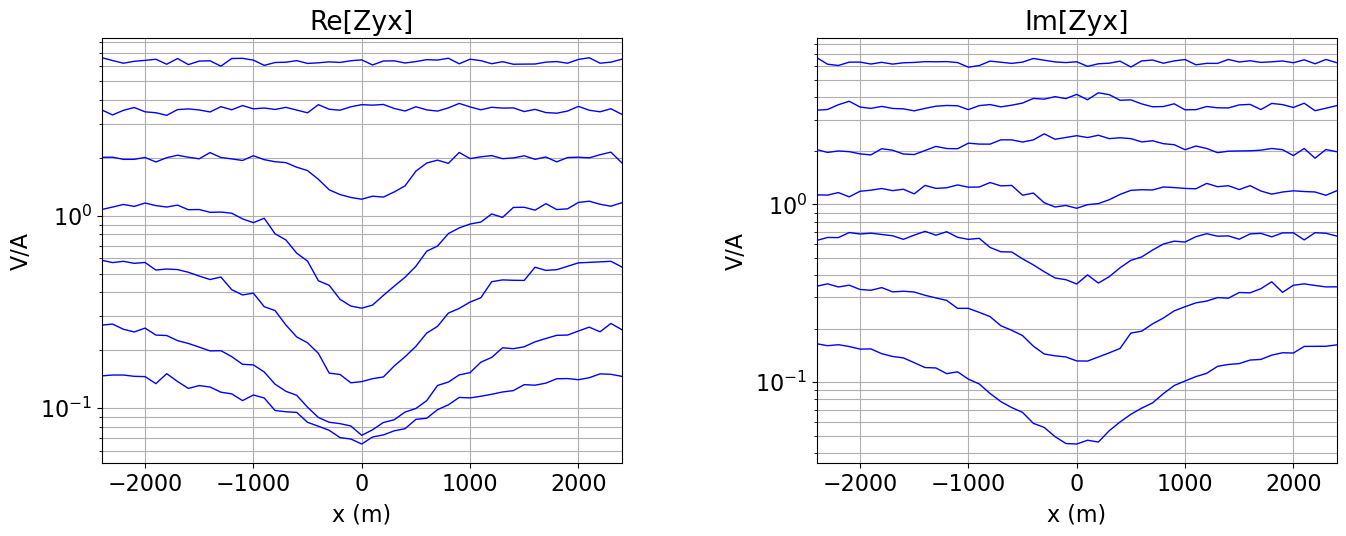

In [19]:
fig = plt.figure(figsize=(13, 5))
ax1 = fig.add_axes([0.05, 0.1, 0.4, 0.85])
ax2 = fig.add_axes([0.6, 0.1, 0.4, 0.85])

for kk in range(len(frequencies)):
    ax1.semilogy(locations[:, 0], dobs_yx[kk, 0, :], 'b', lw=1)
    ax2.semilogy(locations[:, 0], dobs_yx[kk, 1, :], 'b', lw=1)

for ax in [ax1, ax2]:
    ax.set_xlim([locations[:, 0].min(), locations[:, 0].max()])
    ax.set_xlabel("x (m)", labelpad=5)
    ax.grid(which='both')
    ax.set_ylabel("V/A", labelpad=5)

ax1.set_title("Re[Zyx]")
ax2.set_title("Im[Zyx]")

plt.show(fig)

#### Assigning Uncertainties

Inversion with SimPEG requires that we define the uncertainties on our data; that is, an estimate of the standard deviation of the noise on our data assuming it is uncorrelated Gaussian with zero mean. An online resource explaining uncertainties and their role in the inversion can be found [here](https://giftoolscookbook.readthedocs.io/en/latest/content/fundamentals/Uncertainties.html).

**For impedance data,** we generally apply a percent uncertainty to all data; a very small floor is optional. Impedances measured at different frequencies result in real and imaginary impedance values that span many orders of magnitude. A percent uncertainty ensures that data at all frequencies are fit equally. The amplitudes of impedance values are also inversely proportional to the square-root of the apparent conductivity. A percent uncertainty aims to ensure values corresponding to more conductive and more resistive regions at a given frequency are fit equally. Depending on the quality of the data, we may choose a percent uncertainty between 3% - 10%. Here, we apply uncertainties of 3 %.

In [20]:
unc_yx = 0.03 * np.abs(dobs_yx)

#### Defining the Survey

Here, we define the survey geometry for the data being inverted. The data are organized by frequency, then component, then location.

In [21]:
source_list_yx = []

# First loop over frequencies
for freq in frequencies:
    
    receiver_list_yx = []

    # Next loop over receiver types
    for comp in ['real', 'imag']:
        # Locations of corresponding electric and magnetic
        # field measurements set separately
        receiver_list_yx.append(
            nsem.receivers.Impedance(
                locations_e=locations_shifted,
                locations_h=locations_shifted,
                orientation='yx',
                component=comp,
            )
        )

    source_list_yx.append(
        nsem.sources.FictitiousSource(
            receiver_list=receiver_list_yx, frequency=freq,
        )
    )

survey_yx = nsem.survey.Survey(source_list_yx)

#### Defining the Forward Simulation

In SimPEG, the physics of the forward simulation is defined by creating an instance of an appropriate simulation class. For 2D NSEM problems, there are 2 simulation classes:

- [Simulation2DElectricFieldFictitious](xref:simpeg#simpeg.electromagnetics.natural_source.Simulation2DElectricFieldFictitious), which solves for the electric fields on mesh edges. The magnetic fields (defined at cell centers) are transverse to the 2D problem geometry (parallel to geological strike). Thus, we use this class to simulate data types corresponding to the TM mode. These data types are impedance $Z_{xy}$ and admittance $Y_{yx}$
- [Simulation2DMagneticFieldFictitious](xref:simpeg#simpeg.electromagnetics.natural_source.Simulation2DMagneticFieldFictitious), which solves for the magnetic fields on mesh edges. The electric fields (defined at cell centers) are transverse to the 2D problem geometry (parallel to geological strike). Thus, we use this class to simulate data types corresponding to the TE mode. These data types are impedance $Z_{yx}$, tipper $T_{zx}$ and admittance $Y_{xy}$

Since we are inverting data corresponding to impedances $Z_{yx}$, we must use the magnetic field formulation (TE mode).

:::{attention}
Note that because $Z_{xy}$ and $Z_{yx}$ are derived from different modes, we cannot use a single simulation class to invert these data types jointly. Joint inversion will be covered in a separate tutorial.
:::

In [22]:
simulation_yx = nsem.simulation.Simulation2DMagneticFieldFictitious(
    mesh,
    survey=survey_yx,
    sigma_background=sigma_1d,
    sigmaMap=log_conductivity_map,
    solver=get_default_solver()
)

#### Defining the Data

The SimPEG [Data](xref:simpeg#simpeg.data.Data) class is required for inversion and connects the observed data, uncertainties and survey geometry. Note that both the observed data and uncertainties are being assigned as vectors!

In [23]:
data_yx = data.Data(survey=survey_yx, dobs=np.reshape(dobs_yx, -1), standard_deviation=np.reshape(unc_yx, -1))

#### Defining the Data Misfit

To understand the role of the data misfit in the inversion, please visit [this online resource](https://giftoolscookbook.readthedocs.io/en/latest/content/fundamentals/Uncertainties.html).
Here, we use the [L2DataMisfit](xref:simpeg#simpeg.data_misfit.L2DataMisfit) class to define the data misfit. In this case, the data misfit is the L2 norm of the weighted residual between the observed data and the data predicted for a given model. When instantiating the data misfit object within SimPEG, we must assign an appropriate *data object* and *simulation object* as properties.

In [24]:
dmis_yx = data_misfit.L2DataMisfit(simulation=simulation_yx, data=data_yx)

#### Defining the Regularization

To understand the role of the regularization in the inversion, please visit [this online resource](https://giftoolscookbook.readthedocs.io/en/latest/content/fundamentals/ObjectiveFunction.html). Here, we use the [WeightedLeastSquares](xref:simpeg#simpeg.regularization.WeightedLeastSquares) regularization class to constrain the inversion result. Here, the scaling constants that balance the smallness and smoothness terms are set directly. We use the inverse square of the smallest cell size to balance the smallness and smoothness terms. Setting ``alpha_s`` to a very small value will recover the smoothest model. And the reference model is only applied to the smallness term.

By default, the regularization acts on the model parameters; which in the case are the log-conductivities of the active cells. So we need to specify which cells are active in the regularization. And if we wanted to apply the regularization to a function of the model parameters, we would need to set an approprate mapping object using the ``mapping`` keyword argument.

In [25]:
reg_yx = regularization.WeightedLeastSquares(
    mesh,
    active_cells=active_cells,
    alpha_s=1e-8*dh**-2,
    alpha_x=1,
    alpha_y=1,
)

#### Defining the Optimization Algorithm

Here, we use the [InexactGaussNewton](xref:simpeg#simpeg.optimization.InexactGaussNewton) class to solve the optimization problem using the inexact Gauss Newton with conjugate gradient solver. Reasonable default values have generally been set for the properties of each optimization class. However, the user may choose to set custom values; e.g. the accuracy tolerance for the conjugate gradient solver or the number of line searches.

In [26]:
opt_yx = optimization.InexactGaussNewton(
    maxIter=40, maxIterLS=20, cg_maxiter=300, cg_rtol=0.05
)

#### Defining the Inverse Problem

We use the [BaseInvProblem](xref:simpeg#simpeg.inverse_problem.BaseInvProblem) class to fully define the inverse problem that is solved at each beta (trade-off parameter) iteration. The inverse problem requires appropriate *data misfit*, *regularization* and *optimization* objects.

:::{note} Manually set starting beta.
Directives which choose the starting beta (trade-off parameter) for the inversion are no always optimal. In some cases, you may want to set the starting beta manually. To do that, use the kwarg `beta` when instantiating [BaseInvProblem](xref:simpeg#simpeg.inverse_problem.BaseInvProblem).
:::

In [27]:
inv_prob_yx = inverse_problem.BaseInvProblem(dmis_yx, reg_yx, opt_yx)

#### Providing Inversion Directives

Directives represent operations that are carried out during the inversion. Here, we apply common directives for weighted least-squares inversion of 2D ground MT data and describe their roles. These are:

- [UpdateSensitivityWeights](xref:simpeg#simpeg.directives.UpdateSensitivityWeights) (optional): Apply sensitivity weighting to counteract the natural tendency of ground MT inversion to place materials near the electrodes. We can do this because 2D EM problems are small enough for us to store the sensitivities explicitly. Since we only want to counteract the sensitivity to survey geometry, we set `every_iteration=False`. We do not want to use the entire dynamic range of the sensitivities to generate our weighting. So we generally set `threshold_value` to a value betwewen 1e-5 and 1e-3.

- [UpdatePreconditioner](xref:simpeg#simpeg.directives.UpdatePreconditioner): Apply Jacobi preconditioner when solving optimization problem to reduce the number of conjugate gradient iterations. We set `update_every_iteration=True` because the ideal preconditioner is model-dependent.

- [BetaEstimate_ByEig](xref:simpeg#simpeg.directives.BetaEstimate_ByEig): Estimate initial trade-off parameter (beta) by power iteration.

- [BetaSchedule](xref:simpeg#simpeg.directives.BetaSchedule): Size reduction of the trade-off parameter at every beta iteration, and the number of Gauss-Newton iterations for each beta. In general, a `coolingFactor` between 1.5 and 2.5, and `coolingRate` of 3 works well for EM inversion. Cooling beta too quickly will result in portions of the model getting trapped in local minima. And we will not be finding the solution that minimizes the optimization problem if the cooling rate is too small.

- [TargetMisfit](xref:simpeg#simpeg.directives.TargetMisfit): Terminates the inversion when the data misfit equals the target misfit. A `chifact=1` terminates the inversion when the data misfit equals the number of data.


The directive objects are organized in a ``list``. Upon starting the inversion or updating the recovered model at each iteration, the inversion will call each directive within the list **in order**. The order of the directives matters, and SimPEG will throw an error if directives are organized into an improper order. Some directives, like the ``BetaEstimate_ByEig`` are only used when starting the inversion. Other directives, like ``UpdatePreconditionner``, are used whenever the model is updated.

:::{note} Manually set starting beta.
If you set the starting beta manually when instantiating [BaseInvProblem](xref:simpeg#simpeg.inverse_problem.BaseInvProblem), you will need to remove the instance of [BetaEstimate_ByEig](xref:simpeg#simpeg.directives.BetaEstimate_ByEig) in your directives list, otherwise it will override your starting beta.
:::

In [28]:
sensitivity_weights = directives.UpdateSensitivityWeights(
    every_iteration=False, threshold_value=1e-3
)
update_jacobi = directives.UpdatePreconditioner(update_every_iteration=True)
starting_beta = directives.BetaEstimate_ByEig(beta0_ratio=100)
beta_schedule = directives.BetaSchedule(coolingFactor=2.5, coolingRate=3)
target_misfit = directives.TargetMisfit(chifact=1.1)

directives_list_yx = [
    sensitivity_weights,
    update_jacobi,
    starting_beta,
    beta_schedule,
    target_misfit,
]

#### Defining and Running the Inversion

We define the inversion using the [BaseInversion](xref:simpeg#simpeg.inversion.BaseInversion) class. The inversion class must be instantiated with an appropriate *inverse problem* object and *directives list*. The ``run`` method, along with a starting model, is respondible for running the inversion. The output is a 1D numpy.ndarray containing the recovered model parameters

In [29]:
# Here we combine the inverse problem and the set of directives
inv_yx = inversion.BaseInversion(inv_prob_yx, directives_list_yx)

# Run the inversion
recovered_model_yx = inv_yx.run(starting_model)

INFO: simpeg.InvProblem will set Regularization.reference_model to m0.
INFO: simpeg.InvProblem will set Regularization.reference_model to m0.
INFO: simpeg.InvProblem will set Regularization.reference_model to m0.
INFO: simpeg.InvProblem will set Regularization.reference_model to m0.
INFO: simpeg.InvProblem will set Regularization.reference_model to m0.



Running inversion with SimPEG v0.24.1.dev132+g2e9062041


INFO: Directive TargetMisfit: Target data misfit is 754.6


============================ Inexact Gauss Newton ============================
  #     beta     phi_d     phi_m       f      |proj(x-g)-x|  LS    Comment   
-----------------------------------------------------------------------------
   0  9.58e+03  5.39e+05  0.00e+00  5.39e+05                                 
   1  9.58e+03  3.04e+04  8.80e-01  3.88e+04    2.31e+04      0              
   2  9.58e+03  9.60e+03  9.95e-01  1.91e+04    1.85e+03      0              
   3  9.58e+03  4.13e+03  9.50e-01  1.32e+04    1.30e+03      0              
   4  3.83e+03  2.06e+03  1.26e+00  6.88e+03    4.25e+02      0              
   5  3.83e+03  1.96e+03  1.24e+00  6.72e+03    3.27e+02      0              
   6  3.83e+03  1.90e+03  1.25e+00  6.70e+03    2.77e+01      0              
   7  1.53e+03  1.20e+03  1.54e+00  3.56e+03    1.53e+02      0              
   8  1.53e+03  1.17e+03  1.54e+00  3.52e+03    1.47e+02      0              
   9  1.53e+03  1.16e+03  1.54e+00  3.52e+03    1.05e+01      0

#### Comparing Predicted and Observed Data

Below, we plot the observed and predicted impedance data.

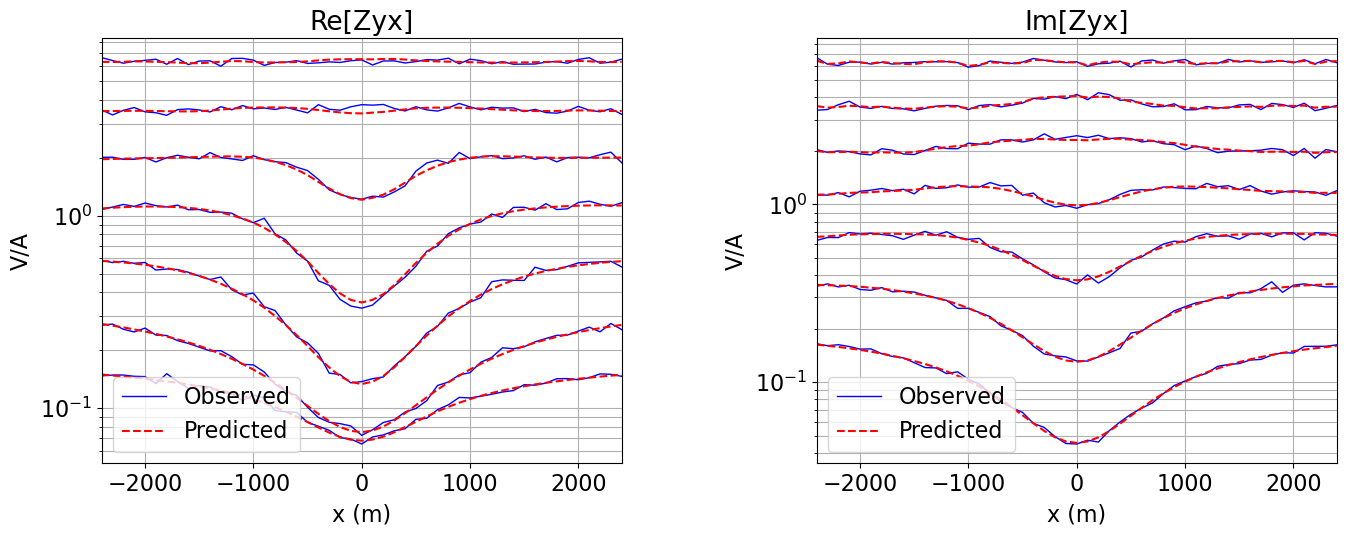

In [30]:
dpred_yx = np.reshape(inv_prob_yx.dpred, (len(frequencies), 2, len(locations)))
                               
fig = plt.figure(figsize=(13, 5))
ax1 = fig.add_axes([0.05, 0.1, 0.4, 0.85])
ax2 = fig.add_axes([0.6, 0.1, 0.4, 0.85])

for kk in range(len(frequencies)):
    ax1.semilogy(locations[:, 0], dobs_yx[kk, 0, :], 'b', lw=1)
    ax1.semilogy(locations[:, 0], dpred_yx[kk, 0, :], 'r--', lw=1.5)
    ax2.semilogy(locations[:, 0], dobs_yx[kk, 1, :], 'b', lw=1)
    ax2.semilogy(locations[:, 0], dpred_yx[kk, 1, :], 'r--', lw=1.5)

for ax in [ax1, ax2]:
    ax.set_xlim([locations[:, 0].min(), locations[:, 0].max()])
    ax.set_xlabel("x (m)", labelpad=5)
    ax.grid(which='both')
    ax.set_ylabel("V/A", labelpad=5)
    ax.legend(['Observed', 'Predicted'], loc='lower left')

ax1.set_title("Re[Zyx]")
ax2.set_title("Im[Zyx]")

plt.show(fig)

#### Plotting the Model

Below, we plot the recovered model.

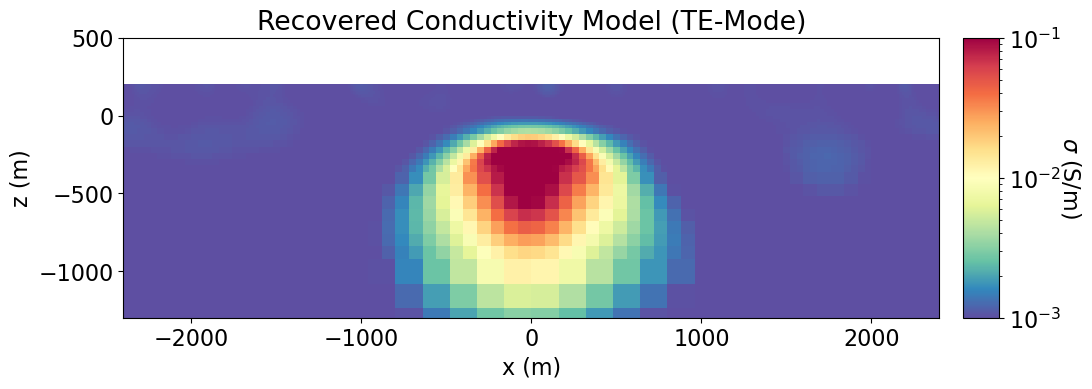

In [31]:
plotting_map = maps.InjectActiveCells(
    mesh, active_cells, value_inactive=np.nan
) * maps.ExpMap(
    nP=n_active
)

norm = LogNorm(vmin=1e-3, vmax=1e-1)

fig = plt.figure(figsize=(12, 4))

ax1 = fig.add_axes([0.14, 0.17, 0.68, 0.7])
mesh.plot_image(
    plotting_map * recovered_model_yx,
    ax=ax1,
    # grid=True,
    pcolor_opts={"norm": norm, "cmap": cmap_default},
)
ax1.set_xlim(locations[:, 0].min(), locations[:, 0].max())
ax1.set_ylim(np.max(topo_2d[:, -1]) - 1500, np.max(topo_2d[:, -1])+300)
ax1.set_title("Recovered Conductivity Model (TE-Mode)")
ax1.set_xlabel("x (m)")
ax1.set_ylabel("z (m)")

ax2 = fig.add_axes([0.84, 0.17, 0.03, 0.7])
cbar = mpl.colorbar.ColorbarBase(
    ax2, norm=norm, orientation="vertical", cmap=cmap_default
)
cbar.set_label(r"$\sigma$ (S/m)", rotation=270, labelpad=15, size=16)

plt.show()

## Apparent Resistivity and Phase Inversion for TM Mode

Here, we invert ground MT data corresponding to the TM mode; i.e. where the magnetic field is transverse to the 2D problem geometry (parallel to geological strike). For this inversion, we invert the apparent resistivities and phases corresponding to $Z_{xy}$ impedances.

#### Assigning Uncertainties

**For apparent resistivity data,** we generally apply a percent uncertainty to all data. Again, we do this in order to fit conductive and resistive structures equally. Depending on the quality of the data, we may choose a percent uncertainty between 5% - 10%. Here, we apply uncertainties of 5%

**For phase data,** uncertainties are generally set to several degrees. Here, we apply uncertainties of 1 degree.

:::{attention} Attention: impedances or apparent resistivity and phase?
The editor generally prefers to invert data represented as impedances since all of the inverted data types are scaled the same.
:::

In [32]:
# Extract apparent resistivity and phase for Zxy impedances
dobs_xy = dobs_all[:, [2, 3], :]

# Assigne uncertainties
unc_xy = np.zeros_like(dobs_xy)
unc_xy[:, 0, :] = 0.05 * np.abs(dobs_xy[:, 0, :])
unc_xy[:, 1, :] = 1.

#### Defining the Survey

Here, we define the survey geometry for the data being inverted. The data are organized by frequency, then component, then location.

In [33]:
source_list_xy = []

# First loop over frequencies
for freq in frequencies:
    
    receiver_list_xy = []

    # Next loop over receiver types
    for comp in ['apparent_resistivity', 'phase']:
        # Locations of corresponding electric and magnetic
        # field measurements set separately
        receiver_list_xy.append(
            nsem.receivers.Impedance(
                locations_e=locations_shifted,
                locations_h=locations_shifted,
                orientation='xy',
                component=comp,
            )
        )

    source_list_xy.append(
        nsem.sources.FictitiousSource(
            receiver_list=receiver_list_xy, frequency=freq,
        )
    )

survey_xy = nsem.survey.Survey(source_list_xy)

#### Defining the Forward Simulation

Since we are now inverting data corresponding to the TM mode, we must use the electric field simulation class.

In [34]:
simulation_xy = nsem.simulation.Simulation2DElectricFieldFictitious(
    mesh,
    survey=survey_xy,
    sigma_background=sigma_1d,
    sigmaMap=log_conductivity_map,
    solver=get_default_solver(),
)

#### Defining the Data

In [35]:
data_xy = data.Data(survey=survey_xy, dobs=np.reshape(dobs_xy, -1), standard_deviation=np.reshape(unc_xy, -1))

#### Defining the Data Misfit

In [36]:
dmis_xy = data_misfit.L2DataMisfit(simulation=simulation_xy, data=data_xy)

#### Defining the Regularization

In [37]:
reg_xy = regularization.WeightedLeastSquares(
    mesh,
    active_cells=active_cells,
    alpha_s=1e-8*dh**-2,
    alpha_x=1,
    alpha_y=1,
)

#### Defining the Optimization Algorithm

In [38]:
opt_xy = optimization.InexactGaussNewton(
    maxIter=40, maxIterLS=20, cg_maxiter=300, cg_rtol=0.05
)

#### Defining the Inverse Problem

In [39]:
inv_prob_xy = inverse_problem.BaseInvProblem(dmis_xy, reg_xy, opt_xy)

#### Providing Inversion Directives

In [40]:
sensitivity_weights = directives.UpdateSensitivityWeights(
    every_iteration=False, threshold_value=1e-3
)
update_jacobi = directives.UpdatePreconditioner(update_every_iteration=True)
starting_beta = directives.BetaEstimate_ByEig(beta0_ratio=100)
beta_schedule = directives.BetaSchedule(coolingFactor=2.5, coolingRate=3)
target_misfit = directives.TargetMisfit(chifact=1.1)

directives_list_xy = [
    sensitivity_weights,
    update_jacobi,
    starting_beta,
    beta_schedule,
    target_misfit,
]

#### Defining and Run the Inversion

In [41]:
# Here we combine the inverse problem and the set of directives
inv_xy = inversion.BaseInversion(inv_prob_xy, directives_list_xy)

# Run the inversion
recovered_model_xy = inv_xy.run(starting_model)

INFO: simpeg.InvProblem will set Regularization.reference_model to m0.
INFO: simpeg.InvProblem will set Regularization.reference_model to m0.
INFO: simpeg.InvProblem will set Regularization.reference_model to m0.
INFO: simpeg.InvProblem will set Regularization.reference_model to m0.
INFO: simpeg.InvProblem will set Regularization.reference_model to m0.



Running inversion with SimPEG v0.24.1.dev132+g2e9062041


INFO: Directive TargetMisfit: Target data misfit is 754.6


============================ Inexact Gauss Newton ============================
  #     beta     phi_d     phi_m       f      |proj(x-g)-x|  LS    Comment   
-----------------------------------------------------------------------------
   0  1.30e+06  3.50e+04  0.00e+00  3.50e+04                                 
   1  1.30e+06  5.55e+03  2.64e-03  8.96e+03    5.64e+04      0              
   2  1.30e+06  3.70e+03  2.21e-03  6.57e+03    7.88e+03      0              
   3  1.30e+06  3.91e+03  1.99e-03  6.49e+03    4.31e+02      0              
   4  5.18e+05  2.61e+03  3.60e-03  4.47e+03    1.84e+03      0              
   5  5.18e+05  2.61e+03  3.59e-03  4.46e+03    2.74e+02      0              
   6  5.18e+05  2.59e+03  3.62e-03  4.46e+03    2.66e+01      0              
   7  2.07e+05  1.70e+03  6.33e-03  3.01e+03    7.32e+02      0              
   8  2.07e+05  1.69e+03  6.33e-03  3.01e+03    1.83e+02      0              
   9  2.07e+05  1.68e+03  6.38e-03  3.01e+03    1.24e+01      0

#### Comparing Observed and Predicted Data

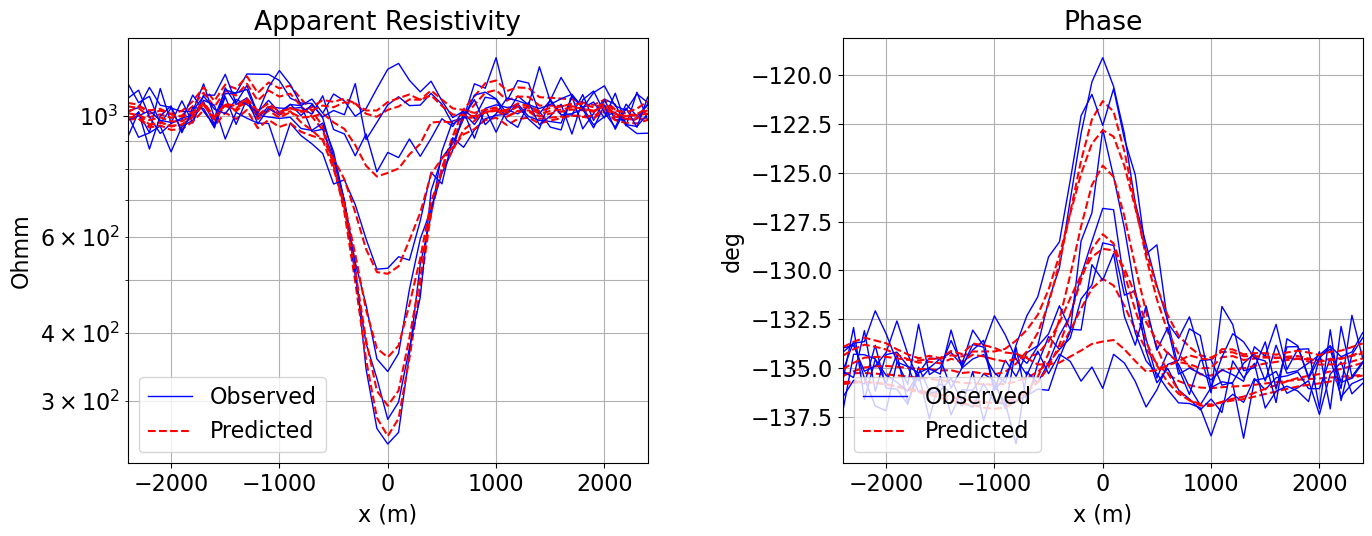

In [42]:
dpred_xy = np.reshape(inv_prob_xy.dpred, (len(frequencies), 2, len(locations)))
    
fig = plt.figure(figsize=(13, 5))
ax1 = fig.add_axes([0.05, 0.1, 0.4, 0.85])
ax2 = fig.add_axes([0.6, 0.1, 0.4, 0.85])

for kk in range(len(frequencies)):
    ax1.semilogy(locations[:, 0], dobs_xy[kk, 0, :], 'b', lw=1)
    ax1.semilogy(locations[:, 0], dpred_xy[kk, 0, :], 'r--', lw=1.5)
    ax2.plot(locations[:, 0], dobs_xy[kk, 1, :], 'b', lw=1)
    ax2.plot(locations[:, 0], dpred_xy[kk, 1, :], 'r--', lw=1.5)

for ax in [ax1, ax2]:
    ax.set_xlim([locations[:, 0].min(), locations[:, 0].max()])
    ax.set_xlabel("x (m)", labelpad=5)
    ax.grid(which='both')
    
    ax.legend(['Observed', 'Predicted'], loc='lower left')

ax1.set_ylabel("Ohmm", labelpad=5)
ax1.set_title("Apparent Resistivity")
ax2.set_ylabel("deg", labelpad=5)
ax2.set_title("Phase")

plt.show(fig)

## Comparing True Model and Recovered Models

Here, we compare the true model to the models recovered by inverting data for the TM and TE modes.

In [43]:
# True model geometries
host_conductivity = 1e-3
block_conductivity = 1e-1
block_corner_1 = np.r_[-320.0, -640.0]
block_corner_2 = np.r_[320., -160.]

# Define the true model
true_model = host_conductivity * np.ones(n_active)
ind_block = model_builder.get_indices_block(
    block_corner_1, block_corner_2, mesh.cell_centers[active_cells, :]
)
true_model[ind_block] = block_conductivity
true_model = np.log(true_model)

C:\Users\devin\AppData\Local\Temp\ipykernel_29500\1860862533.py:9: BreakingChangeWarning: Since SimPEG v0.25.0, the 'get_indices_block' function returns a single array with the cell indices, instead of a tuple with a single element. This means that we don't need to unpack the tuple anymore to access to the cell indices.
If you were using this function as in:

    ind = get_indices_block(p0, p1, mesh.cell_centers)[0]

Make sure you update it to:

    ind = get_indices_block(p0, p1, mesh.cell_centers)

To hide this warning, add this to your script or notebook:

    import warnings
    from simpeg.utils import BreakingChangeWarning

    warnings.filterwarnings(action='ignore', category=BreakingChangeWarning)

  ind_block = model_builder.get_indices_block(


:::{attention} TE vs TM mode inversion
You will notice that the inversion for the TM mode underestimates the electrical conductivity of the recovered target. This occurs due to a phenomenon called galvanic screening (or the shielding effect), which does not impact the TE mode in the same way - the TM-mode produces the build-up of galvanic charges on target boundaries, whereas the TM-mode does not. For reference, see Wannamaker et al., 1984.
:::

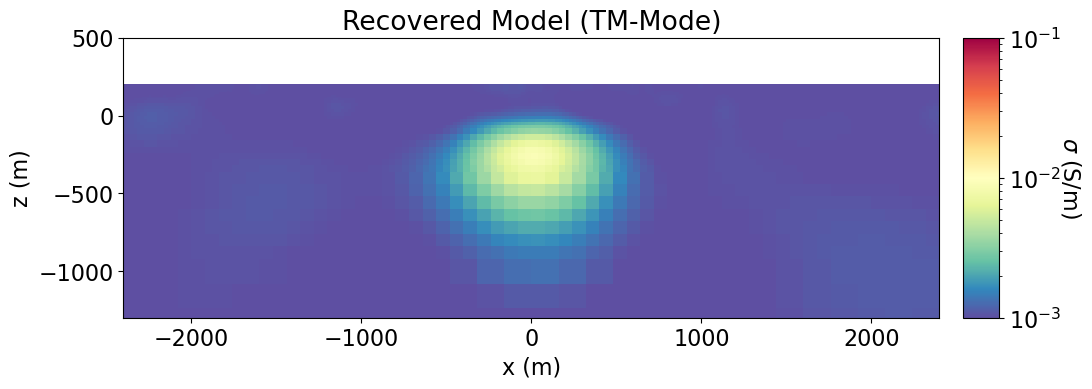

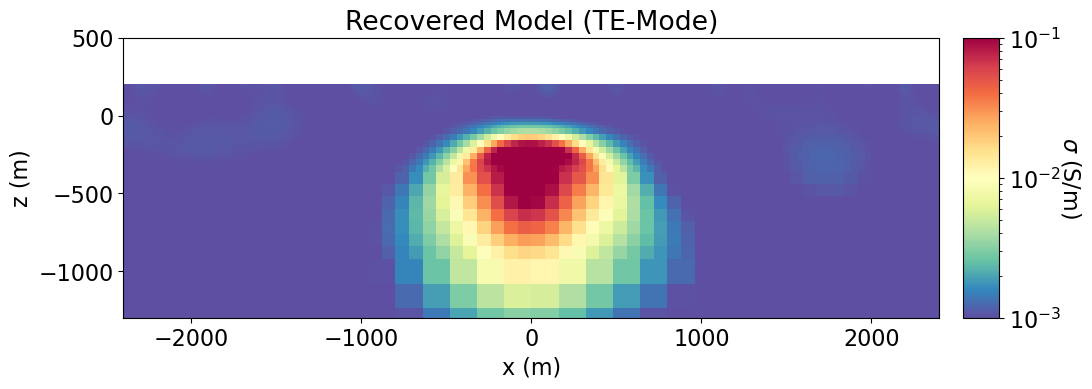

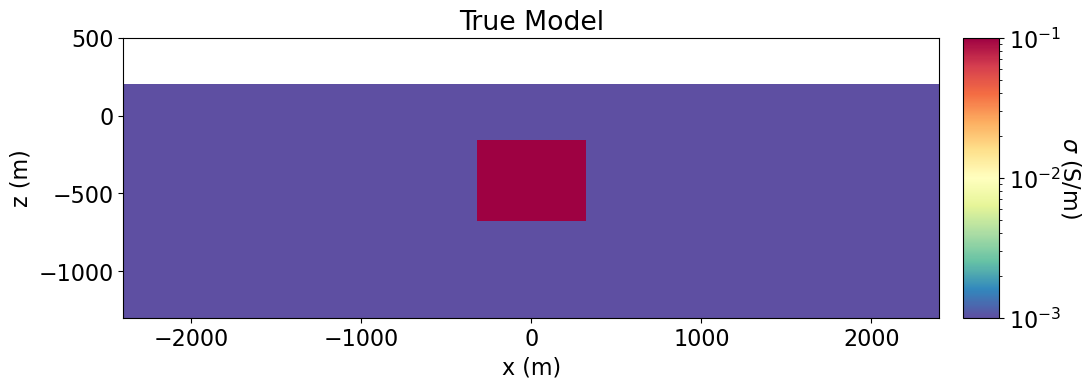

In [44]:
norm = LogNorm(vmin=1e-3, vmax=1e-1)

models_list = [recovered_model_xy, recovered_model_yx, true_model]
titles_list = ['Recovered Model (TM-Mode)', 'Recovered Model (TE-Mode)', 'True Model']

for mod, title_str in zip(models_list, titles_list):

    fig = plt.figure(figsize=(12, 4))
    ax1 = fig.add_axes([0.14, 0.17, 0.68, 0.7])
    mesh.plot_image(
        plotting_map * mod.copy(),
        ax=ax1,
        pcolor_opts={"norm": norm, "cmap": cmap_default},
    )
    ax1.set_xlim(locations[:, 0].min(), locations[:, 0].max())
    ax1.set_ylim(np.max(topo_2d[:, -1]) - 1500, np.max(topo_2d[:, -1])+300)
    ax1.set_title(title_str)
    ax1.set_xlabel("x (m)")
    ax1.set_ylabel("z (m)")
    
    ax2 = fig.add_axes([0.84, 0.17, 0.03, 0.7])
    cbar = mpl.colorbar.ColorbarBase(
        ax2, norm=norm, orientation="vertical", cmap=cmap_default
    )
    cbar.set_label(r"$\sigma$ (S/m)", rotation=270, labelpad=15, size=16)
    
    plt.show()